# Домашнее задание 4 - Работа с пропусками в данных

In [1]:
!pip install missingno -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

## 1. Загрузка датасета

In [3]:
df = pd.read_csv('loan_prediction_dataset.csv')
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [4]:
df.shape

(614, 13)

Датасет загружен: 614 строк, 13 столбцов

## 2. Основная информация о датасете

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Видим, что в нескольких столбцах количество non-null значений меньше 614 - значит, есть пропуски. Типы данных: часть столбцов числовые (int64, float64), часть - объектные (категориальные).

In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


По числовым признакам: доход заявителей сильно варьируется (от 150 до 81000), сумма кредита - от 9 до 700. Credit_History принимает значения 0 и 1.

По категориальным: большинство заявителей - мужчины (Male), женаты (Yes), с высшим образованием (Graduate).

## 3. Таблица пропусков

In [8]:
missing = pd.DataFrame({
    'Пропуски': df.isnull().sum(),
    'Процент, %': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing['Пропуски'] > 0]
missing.sort_values('Процент, %', ascending=False)

,Пропуски,"Процент, %"
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


Больше всего пропусков в Credit_History (\~8%), далее Self_Employed (~5%). Остальные столбцы - менее 4%. В целом пропусков немного, можно заполнять.

## 4. Визуализация пропусков

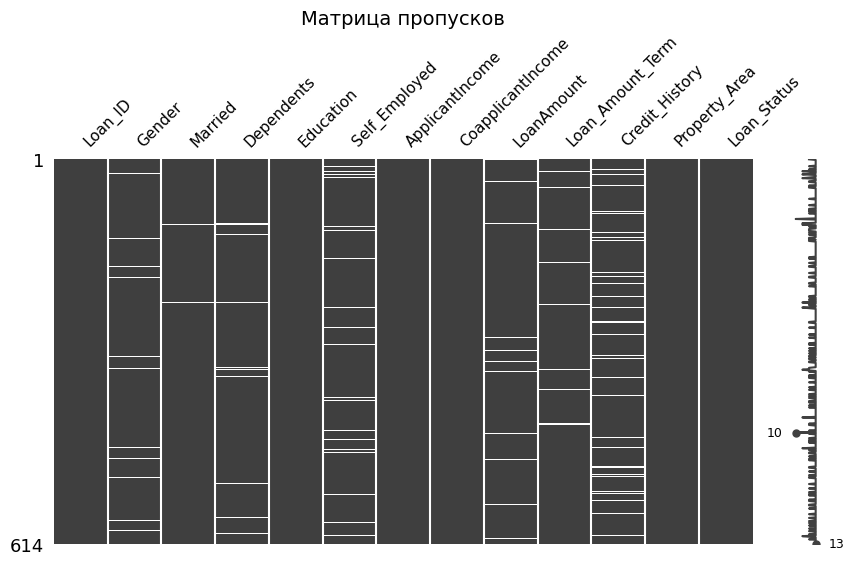

In [9]:
msno.matrix(df, figsize=(10, 5), fontsize=11)
plt.title('Матрица пропусков', fontsize=14)
plt.show()

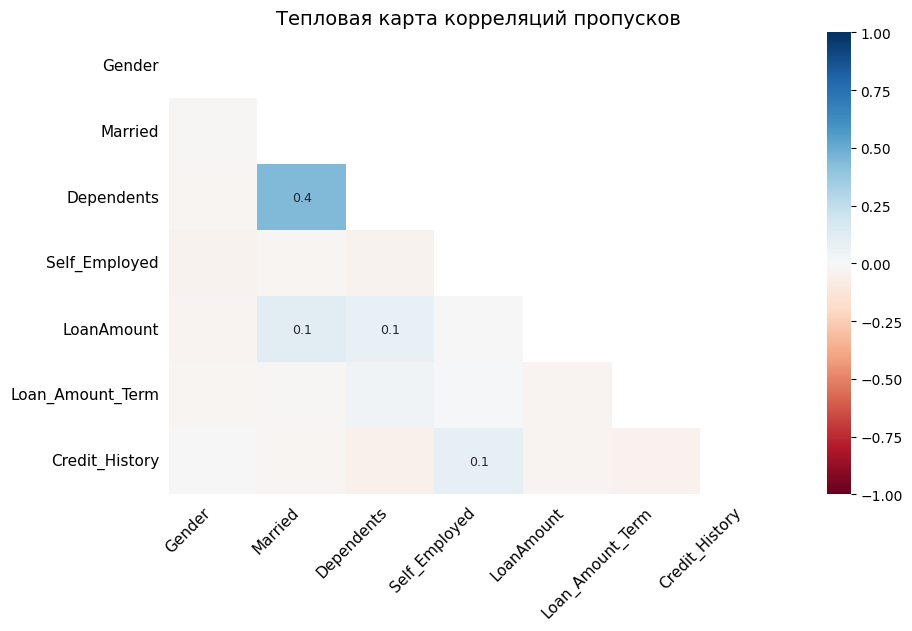

In [10]:
msno.heatmap(df, figsize=(10, 6), fontsize=11)
plt.title('Тепловая карта корреляций пропусков', fontsize=14)
plt.show()

## 5. Интерпретация графиков

**Матрица пропусков:**

На матрице видно, что большинство столбцов заполнены почти полностью - пропусков мало. Наиболее заметные пропуски - в столбцах Credit_History и Self_Employed. Пропуски расположены хаотично, без явного паттерна - то есть данные, скорее всего, пропущены случайно (MCAR или MAR).

**Тепловая карта:**

Тепловая карта показывает корреляцию между наличием пропусков в разных столбцах. Значения близки к нулю - это значит, что пропуски в одном столбце практически не связаны с пропусками в другом. Это хороший знак: пропуски не образуют систематических паттернов и их можно заполнять независимо друг от друга.

## 6. Разделение признаков с пропусками на числовые и категориальные

In [11]:
cols_with_na = df.columns[df.isnull().any()]

num_cols = df[cols_with_na].select_dtypes(include='number').columns.tolist()
cat_cols = df[cols_with_na].select_dtypes(include='object').columns.tolist()

print('Числовые признаки с пропусками:', num_cols)
print('Категориальные признаки с пропусками:', cat_cols)

Числовые признаки с пропусками: ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Категориальные признаки с пропусками: ['Gender', 'Married', 'Dependents', 'Self_Employed']


Числовые: LoanAmount, Loan_Amount_Term, Credit_History — это всё float64

Категориальные: Gender, Married, Dependents, Self_Employed — это строковые признаки

## 7. Заполнение пропусков

**Стратегия заполнения:**

- **Числовые признаки** заполняем **медианой**. Медиана устойчива к выбросам, а в данных есть сильный разброс (например, в LoanAmount и ApplicantIncome). Среднее было бы искажено выбросами.

- **Категориальные признаки** заполняем **модой** (самым частым значением). Для категориальных данных это наиболее логичный подход, т.к. среднее или медиану для них посчитать нельзя.

In [12]:
# сохраним статистики до заполнения
desc_before_num = df[num_cols].describe()
desc_before_cat = df[cat_cols].describe()

In [13]:
# заполняем числовые - медианой
for col in num_cols:
    median_val = df[col].median()
    print(f'{col}: заполняем медианой = {median_val}')
    df[col] = df[col].fillna(median_val)

LoanAmount: заполняем медианой = 128.0
Loan_Amount_Term: заполняем медианой = 360.0
Credit_History: заполняем медианой = 1.0


In [14]:
# заполняем категориальные - модой
for col in cat_cols:
    mode_val = df[col].mode()[0]
    print(f'{col}: заполняем модой = {mode_val}')
    df[col] = df[col].fillna(mode_val)

Gender: заполняем модой = Male
Married: заполняем модой = Yes
Dependents: заполняем модой = 0
Self_Employed: заполняем модой = No


## 8. Проверка заполнения

In [15]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


Пропусков не осталось - все столбцы заполнены полностью

## 9. Сравнение статистик до и после заполнения

### Числовые признаки

In [16]:
desc_after_num = df[num_cols].describe()

print('=== ДО заполнения ===')
display(desc_before_num)
print('\n=== ПОСЛЕ заполнения ===')
display(desc_after_num)

=== ДО заполнения ===


,LoanAmount,Loan_Amount_Term,Credit_History
count,592.000000,600.00000,564.000000
mean,146.412162,342.00000,0.842199
std,85.587325,65.12041,0.364878
min,9.000000,12.00000,0.000000
25%,100.000000,360.00000,1.000000
50%,128.000000,360.00000,1.000000
75%,168.000000,360.00000,1.000000
max,700.000000,480.00000,1.000000



=== ПОСЛЕ заполнения ===


,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000
mean,145.752443,342.410423,0.855049
std,84.107233,64.428629,0.352339
min,9.000000,12.000000,0.000000
25%,100.250000,360.000000,1.000000
50%,128.000000,360.000000,1.000000
75%,164.750000,360.000000,1.000000
max,700.000000,480.000000,1.000000


### Категориальные признаки

In [17]:
desc_after_cat = df[cat_cols].describe()

print('=== ДО заполнения ===')
display(desc_before_cat)
print('\n=== ПОСЛЕ заполнения ===')
display(desc_after_cat)

=== ДО заполнения ===


,Gender,Married,Dependents,Self_Employed
count,601,611,599,582
unique,2,2,4,2
top,Male,Yes,0,No
freq,489,398,345,500



=== ПОСЛЕ заполнения ===


,Gender,Married,Dependents,Self_Employed
count,614,614,614,614
unique,2,2,4,2
top,Male,Yes,0,No
freq,502,401,360,532


**Комментарий по изменениям:**

- **Числовые признаки:** count вырос до 614 (было меньше из-за пропусков). Среднее и медиана практически не изменились - это ожидаемо, т.к. мы заполняли медианой, что не сдвигает центральную тенденцию. Стандартное отклонение немного уменьшилось потому что добавленные значения (медианы) находятся в центре распределения

- **Категориальные признаки:** count вырос до 614. Частота самого популярного значения (top/freq) увеличилась, что логично - мы добавили именно моду. Само модальное значение не изменилось. Распределение категорий стало чуть менее сбалансированным, но при таком малом количестве пропусков это несущественно